In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

c:\Users\AB\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\AB\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("haizelabs/banking77")

README.md:   0%|          | 0.00/275 [00:00<?, ?B/s]

c:\Users\AB\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\AB\.cache\huggingface\hub\datasets--haizelabs--banking77. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


train.csv:   0%|          | 0.00/22.6M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/6.93M [00:00<?, ?B/s]

synth_easy.csv:   0%|          | 0.00/12.2M [00:00<?, ?B/s]

synth_hard.csv:   0%|          | 0.00/12.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

Generating synth_easy split:   0%|          | 0/5146 [00:00<?, ? examples/s]

Generating synth_hard split:   0%|          | 0/5271 [00:00<?, ? examples/s]

In [4]:
train_df = pd.DataFrame(ds["train"])
test_df = pd.DataFrame(ds["test"])

print("Training data:", train_df.shape)
print("Testing data:", test_df.shape)

print(train_df.head())

Training data: (10003, 13)
Testing data: (3080, 13)
                                                text  label_gt  label_oracle  \
0                     I am still waiting on my card?        11            11   
1  What can I do if my card still hasn't arrived ...        11            11   
2  I have been waiting over a week. Is the card s...        11            11   
3  Can I track my card while it is in the process...        11            12   
4  How do I know if I will get my card, or if it ...        11            11   

                                      message_system  \
0  You are a helpful assistant that classifies cu...   
1  You are a helpful assistant that classifies cu...   
2  You are a helpful assistant that classifies cu...   
3  You are a helpful assistant that classifies cu...   
4  You are a helpful assistant that classifies cu...   

                                        message_user  message_assistant_gt  \
0                     I am still waiting on my card?

In [5]:
print(train_df.isnull().sum())
print(test_df.isnull().sum())

text                             0
label_gt                         0
label_oracle                     0
message_system                   0
message_user                     0
message_assistant_gt             0
message_assistant_oracle         0
label_o3mini                     0
message_assistant_o3mini         0
id                               0
confidence_selfdeclared          0
confidence_resample              0
confidence_selfdeclared_TRACT    0
dtype: int64
text                             0
label_gt                         0
label_oracle                     0
message_system                   0
message_user                     0
message_assistant_gt             0
message_assistant_oracle         0
label_o3mini                     0
message_assistant_o3mini         0
id                               0
confidence_selfdeclared          0
confidence_resample              0
confidence_selfdeclared_TRACT    0
dtype: int64


In [7]:
print(train_df["label_gt"].value_counts().sort_index())

label_gt
0     159
1     110
2     126
3      87
4     127
     ... 
72     41
73    135
74    121
75    180
76    163
Name: count, Length: 77, dtype: int64


In [10]:
train_df["category"] = train_df["label_gt"].astype(str)

test_df["category"] = test_df["label_gt"].astype(str)

print(train_df[["text", "category"]].head())

                                                text category
0                     I am still waiting on my card?       11
1  What can I do if my card still hasn't arrived ...       11
2  I have been waiting over a week. Is the card s...       11
3  Can I track my card while it is in the process...       11
4  How do I know if I will get my card, or if it ...       11


In [13]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    
  
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()
    
   
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

In [15]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

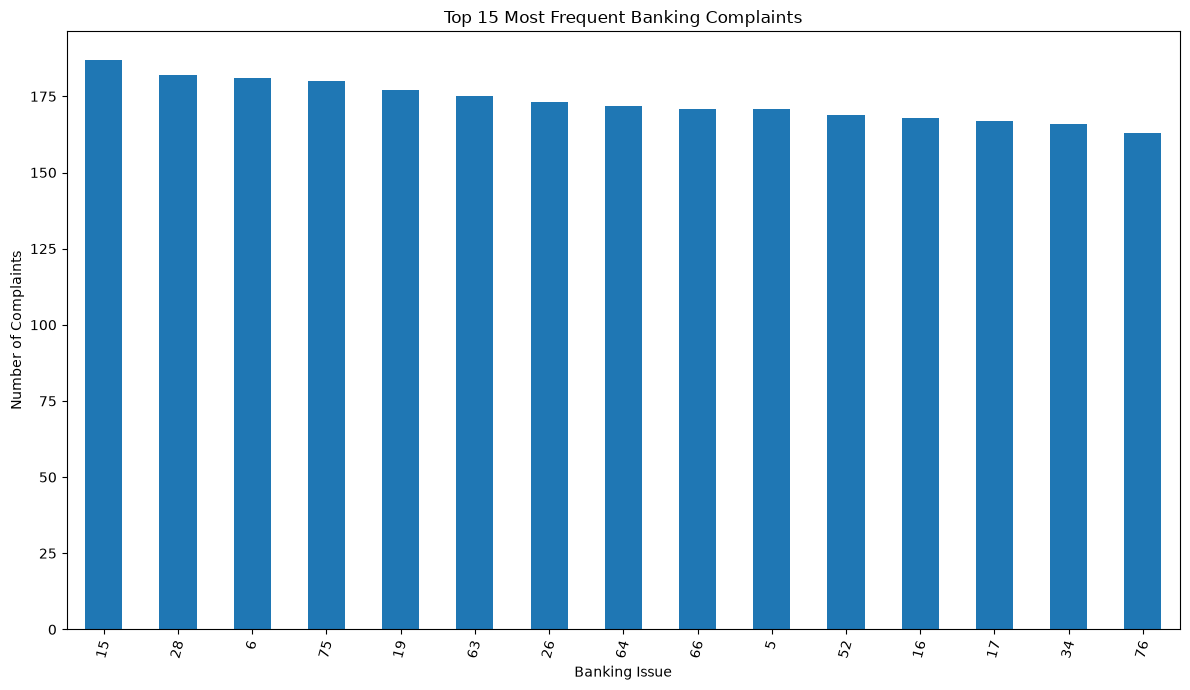

In [14]:
category_counts = train_df["category"].value_counts()

plt.figure(figsize=(12, 7))

category_counts.head(15).plot(kind="bar")

plt.title("Top 15 Most Frequent Banking Complaints")
plt.xlabel("Banking Issue")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

In [16]:
from collections import Counter

all_words = " ".join(train_df["clean_text"]).split()

word_counts = Counter(all_words)

print(word_counts.most_common(20))

[('card', 2672), ('account', 1348), ('money', 1130), ('transfer', 1081), ('get', 808), ('payment', 746), ('need', 698), ('cash', 690), ('top', 616), ('exchange', 549), ('charged', 528), ('please', 514), ('atm', 474), ('app', 469), ('fee', 456), ('use', 427), ('pending', 424), ('topup', 394), ('help', 368), ('long', 361)]


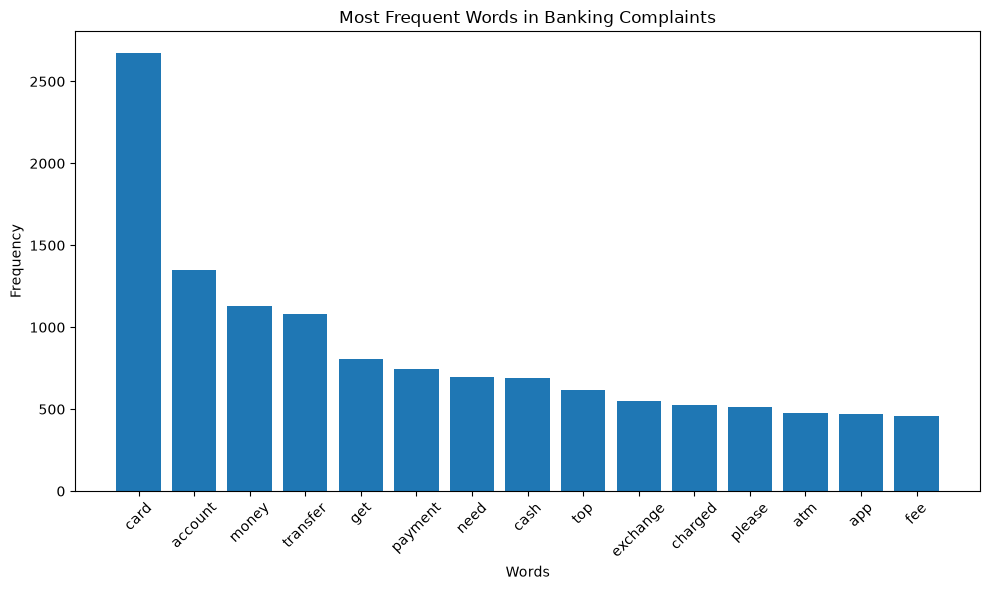

In [17]:
words = [x[0] for x in word_counts.most_common(15)]
counts = [x[1] for x in word_counts.most_common(15)]

plt.figure(figsize=(10, 6))

plt.bar(words, counts)

plt.title("Most Frequent Words in Banking Complaints")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
X_text = train_df["clean_text"]
y = train_df["label_gt"]

X_test_text = test_df["clean_text"]
y_test = test_df["label_gt"]

KeyError: 'label'

In [18]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_text)

X_test_tfidf = tfidf.transform(X_test_text)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

NameError: name 'X_text' is not defined